# CIC-IDS2017 imbalance techniques experiment

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier, plot_importance
import matplotlib.pyplot as plt
import time


RANDOM_STATE = 5

In [2]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score
)   
    
def evaluate(preds, y, target_names, title=""):
    """Print report + F2, show confusion matrix. Returns the predictions."""
    print(f"--- {title} ---")
    print(f"accuracy: {(preds == y).mean():.4f}")
    print(classification_report(y, preds, target_names=target_names, zero_division=0))
    cm = confusion_matrix(y, preds) #labels=target_names)

    fig, ax = plt.subplots(figsize=(10, 10))
    classes = ["B", "bot", "DDoS", "DoS GE", "DoS H", "DoS shttp", 
               "DoS sl", "FTP-Pa.", "HB", "Inf.", "PoSc", "SSH-Pa.", 
               "BF", "SQL inj.", "XSS"]
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test,
        preds,
        display_labels=classes,
        ax=ax
    )
    ax.tick_params(axis='both', labelsize=7)
    for text in ax.texts:
        text.set_fontsize(8)
    plt.show()
    
    fpr = cm[0, 1:].sum() / cm[0, :].sum()
    print(f"FPR: {fpr}")
    
    true_anomalous_alerts = np.trace(cm[1:, 1:])
    all_anomalous_alerts = cm[:, 1:].sum()
    alert_precision = true_anomalous_alerts / all_anomalous_alerts
    print(f"alert precision: {alert_precision}")
    
    recall = np.diag(cm) / cm.sum(axis=1)
    anomalous_recall = recall[1:]
    anomalous_macro_recall = np.mean(anomalous_recall)
    print(f"macro attack recall: {anomalous_macro_recall}")

    class_support = cm.sum(axis=1)[1:]
    anomalous_weighted_recall = np.average(
        anomalous_recall,
        weights=class_support
    )
    print(f"weighted attack recall: {anomalous_weighted_recall}")

## Data Preparation

In [3]:
import glob
files = glob.glob("data/*.csv")

### Loading and Cleaning
First we must concatenate all 8 csv files. They have odd column names with trailing spaces, so names must be normalised. We then clean any rows that contain infinity or NaNs.

In [4]:
df_before_dropna = (
    pd.concat((pd.read_csv(f, encoding_errors="replace") for f in files), ignore_index=True)
    .rename(columns=lambda s: s.strip())
    .replace([np.inf, -np.inf], np.nan)
)

In [6]:
dropped = df_before_dropna[df_before_dropna.isna().any(axis=1)]
print(dropped["Label"].value_counts())
df = df_before_dropna.dropna()
print(df["Label"].value_counts())

Label
BENIGN         1777
DoS Hulk        949
PortScan        126
Bot              10
FTP-Patator       3
DDoS              2
Name: count, dtype: int64
Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


Dropping NaN values does not harm the model, we aren't dropping from rare classes.

### Down-Casting
Down-casting from float64 is inherantly lossy, so below checks if loss > 1e-07 when casting to float32. 

In [7]:
for col in df.select_dtypes("float").columns:
    orig = df[col].astype("float64")
    back = df[col].astype("float32").astype("float64")
    
    # largest relative error introduced
    rel_err = ((back - orig).abs() / orig.abs().replace(0, np.nan)).max()
    print(col, rel_err)

Fwd Packet Length Mean 5.8808532115861154e-08
Fwd Packet Length Std 5.946117860918782e-08
Bwd Packet Length Mean 5.894248777797077e-08
Bwd Packet Length Std 5.9490018992827366e-08
Flow Bytes/s 5.952342611128164e-08
Flow Packets/s 5.9561211665086304e-08
Flow IAT Mean 5.960429305881185e-08
Flow IAT Std 5.9494370761997505e-08
Fwd IAT Mean 5.9603710426339974e-08
Fwd IAT Std 5.952222580744429e-08
Bwd IAT Mean 5.9604513325274406e-08
Bwd IAT Std 5.958431058164412e-08
Fwd Packets/s 5.9561211665086304e-08
Bwd Packets/s 5.9527607936747004e-08
Packet Length Mean 5.9111707366382436e-08
Packet Length Std 5.9580811682697106e-08
Packet Length Variance 5.945458386220663e-08
Average Packet Size 5.8961517633826155e-08
Avg Fwd Segment Size 5.8808532115861154e-08
Avg Bwd Segment Size 5.894248777797077e-08
Active Mean 5.957727658327655e-08
Active Std 5.9495230822478896e-08
Idle Mean 5.960207627408825e-08
Idle Std 5.9463410133870844e-08


In [8]:
# Safely downcasts 64-bit data to 32-bit where there is no information loss
def down_cast(d):
    original_size = d.memory_usage(deep=True).sum()
    for col in d.select_dtypes("integer").columns:
        d[col] = pd.to_numeric(d[col], downcast="integer")
    for col in d.select_dtypes("float").columns:
        d[col] = pd.to_numeric(d[col], downcast="float")
    final_size = d.memory_usage(deep=True).sum()
    print("Size savings: " + str(original_size-final_size) + " bytes")
    return d

df = down_cast(df)

Size savings: 882297312 bytes


We save >0.88 GB for our precious, precious RAM. 

### De-duplication

In [9]:
original_size = df.shape[0]
print(df["Label"].value_counts())
df = df.drop_duplicates()
new_size = df.shape[0]
print(df["Label"].value_counts())
original_size-new_size

Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64
Label
BENIGN                        2095051
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack �

307084

CIC-IDS2017 contains a lot of duplicate rows (307,084!!). These must be removed to prevent leakage - a row could be in the training set and then it's twin could appear in the test set. Now we definitely don't want that! It would produce lovely metrics but a terrible model.

### Normalising non utf-8 characters

In [33]:
import unicodedata

def normalise(s):
    return (unicodedata.normalize("NFKD", str(s))
            .encode("ascii", "ignore")
            .decode("ascii"))

X = df.drop(["Label", "Destination Port", "Init_Win_bytes_forward",
            "Fwd Header Length", "Total Fwd Packets", "min_seg_size_forward",
            "SYN Flag Count", "Bwd Packet Length Mean"], axis=1)
y = df["Label"].apply(normalise)

In [34]:
feature_names = X.columns

In [35]:
y.value_counts()

Label
BENIGN                       2095051
DoS Hulk                      172846
DDoS                          128014
PortScan                       90694
DoS GoldenEye                  10286
FTP-Patator                     5931
DoS slowloris                   5385
DoS Slowhttptest                5228
SSH-Patator                     3219
Bot                             1948
Web Attack  Brute Force         1470
Web Attack  XSS                  652
Infiltration                      36
Web Attack  Sql Injection         21
Heartbleed                        11
Name: count, dtype: int64

### Data splitting

In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42)
X_test, X_cv, y_test, y_cv       = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42)

In [38]:
X_train.shape[0] + X_test.shape[0] + X_cv.shape[0] == df.shape[0]

True

In [39]:
# import seaborn as sns
# # THERE IS NO CATEGORICAL DATA
# # Destination port is categorical masquerading as numerical!
# corr = X_train.corr()

# plt.figure(figsize=(12,10))
# sns.heatmap(corr, cmap='coolwarm', linewidth=0.5)
# plt.title('Feature Correlation Heatmap (trining set)')
# plt.tight_layout()
# plt.show()

### Scaling
XGBoost doesn't actually need scaling....

In [40]:
from sklearn.preprocessing import StandardScaler

In [41]:
std_scaler = StandardScaler().fit(X_train)
X_train = std_scaler.transform(X_train)
X_cv    = std_scaler.transform(X_cv)
X_test  = std_scaler.transform(X_test)

In [42]:
X_train.shape

(1512475, 71)

In [63]:
le.classes_

array(['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk',
       'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed',
       'Infiltration', 'PortScan', 'SSH-Patator',
       'Web Attack  Brute Force', 'Web Attack  Sql Injection',
       'Web Attack  XSS'], dtype=object)

In [62]:
np.unique_counts(y_train)

UniqueCountsResult(values=array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]), counts=array([1257132,    1161,   76876,    6163,  103581,    3162,    3261,
          3510,       7,      22,   54324,    1968,     918,       9,
           381]))

## Imbalance experiment
This dataset is super imbalanced. There are >2 million benign flows, and some attack categories are in the hundreds of thousands. Wheras Heartbleed, Sql injection, and Infiltration attack classes have less than 100 examples.
We will compare three methods for handling imbalance:
- Modifying class weights;
- Undersampling the majority;
- SMOTE.

These will be evaluated mostly factoring macro-recall, as our aim is to minimise missed attacks at the cost of reduced precision (an increase in false positives).

This will be a fair test, controlling for:
- train, test and CV split (these sets will be constant);
- scaling and other pre-processing;
- choose of model (XGBoost);
- hyper-parameters. To reduce computation cost while maintaining a fair comparison, all experiments will use identical hyper-parameters with a learning rate of 0.2 and a max 300 estimators.

In [43]:
hyper_params = {"n_estimators": 300, "learning_rate": 0.1, "verbosity": 1,
             "random_state": RANDOM_STATE,  "early_stopping_rounds": 20, "tree_method": "hist"}
eval_set = [(X_cv, y_cv)]

## 1. Baseline / Control
We must first establish a baseline to compare the 3 techniques to. Hopefully they won't all just be worse than the baseline!

--- baseline ---
accuracy: 0.9978
                           precision    recall  f1-score   support

                   BENIGN       1.00      1.00      1.00    418794
                      Bot       0.94      0.45      0.61       403
                     DDoS       1.00      1.00      1.00     25716
            DoS GoldenEye       1.00      0.99      0.99      2055
                 DoS Hulk       1.00      0.99      1.00     34562
         DoS Slowhttptest       0.95      0.99      0.97      1042
            DoS slowloris       1.00      0.99      0.99      1016
              FTP-Patator       1.00      0.99      1.00      1185
               Heartbleed       1.00      1.00      1.00         3
             Infiltration       1.00      0.80      0.89         5
                 PortScan       0.99      1.00      0.99     18321
              SSH-Patator       0.98      0.95      0.97       639
  Web Attack  Brute Force       0.71      0.84      0.77       280
Web Attack  Sql Injection  

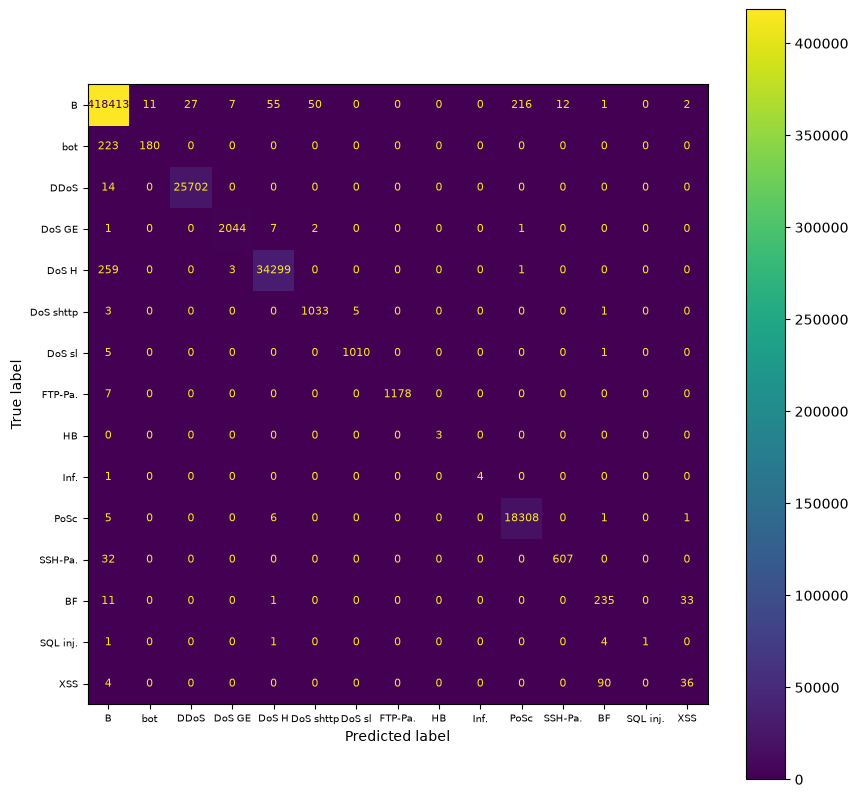

FPR: [2.62658968e-05 6.44708377e-05 1.67146616e-05 1.31329484e-04
 1.19390440e-04 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 5.15766702e-04 2.86537056e-05 2.38780880e-06
 0.00000000e+00 4.77561761e-06]
alert precision: 0.9936721492386621
macro attack recall: 0.8157836858703826
weighted attack recall: 0.9915186729768989


In [44]:
xgb_model = XGBClassifier(**hyper_params)
xgb_model.fit(X_train, y_train, eval_set = [(X_cv, y_cv)], verbose=0)

preds = xgb_model.predict(X_test)
evaluate(preds, y_test, le.classes_, "baseline")

# from sklearn.inspection import permutation_importance

# result = permutation_importance(
#     xgb_model,
#     X_test,
#     y_test,
#     n_repeats=5,
#     random_state=RANDOM_STATE,
#     scoring="accuracy",
#     n_jobs=-1,
# )

# importance = pd.Series(
#     result.importances_mean,
#     index=feature_names
# ).sort_values(ascending=False)

# print(importance.head(15))

del preds, xgb_model

## 2. Sample weights
We will now use the XGBoost `sample_weight` parameter to weigh attack classes with a greater cost proportional to how rare they are. This can be automatically calculated with sklearn `compute_sample_weight` with "balanced" mode which adjusts weights inversely proportional to class frequencies. We will calculate our sample weights ONLY on the training set to avoid leakage.

--- sample weights ---
accuracy: 0.9874
                           precision    recall  f1-score   support

                   BENIGN       1.00      0.99      0.99    418794
                      Bot       0.10      0.97      0.18       403
                     DDoS       1.00      1.00      1.00     25716
            DoS GoldenEye       0.98      1.00      0.99      2055
                 DoS Hulk       0.99      1.00      0.99     34562
         DoS Slowhttptest       0.94      0.99      0.97      1042
            DoS slowloris       0.92      0.99      0.96      1016
              FTP-Patator       0.96      1.00      0.98      1185
               Heartbleed       0.75      1.00      0.86         3
             Infiltration       1.00      0.80      0.89         5
                 PortScan       0.99      1.00      0.99     18321
              SSH-Patator       0.88      1.00      0.94       639
  Web Attack  Brute Force       0.39      0.72      0.50       280
Web Attack  Sql Injec

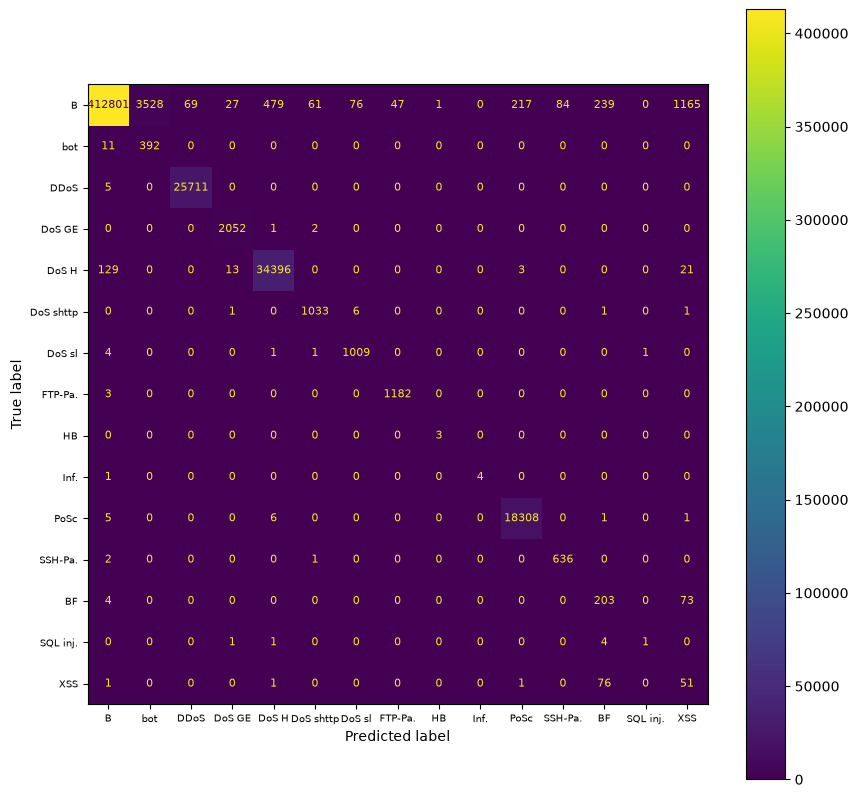

FPR: 0.014310138158617362
alert precision: 0.9318909553469603
macro attack recall: 0.857353518010516
weighted attack recall: 0.9955133311466192


In [47]:
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight("balanced", y_train)

xgb_sw = XGBClassifier(**hyper_params)
xgb_sw.fit(X_train, y_train, eval_set = eval_set, sample_weight=sample_weights, verbose=0)

preds_sw = xgb_sw.predict(X_test)
evaluate(preds_sw, y_test, le.classes_, "sample weights")

del xgb_sw, preds_sw, sample_weights

## 3. Undersampling
There are two classes of undersampling algorithms, **generation** and **selection**. They both involve creating a new set S' from an original set S, where |S'| < |S|. However, in generation S' ⊄ S wheras in selection S' ⊂ S. 

For the sake of fairness, we will attempt to use a common under-sampling strategy. This will be to tune the majority classes down to have a frequency equal to the third quartile (median would remove far too m

### 3.1 Generation
For generation we will use the cluster centroids method from imbalanced learn, which uses K-means reduce a majority class to the centroids of K-means. Because cluster centroids is a very computationally demanding method, I will first do a trial run with 50k entries. This will let me see if a threshold of the frequency at the third quartile is reasonable and tractable.

In [48]:
import time
from collections import Counter
from sklearn.cluster import MiniBatchKMeans
from imblearn.under_sampling import ClusterCentroids

X_small, y_small = X_train[:50000], y_train[:50000]

counts = Counter(y_train)
vals = list(counts.values())
T_under = int(np.percentile(vals, 75))   # Q3
time_counts = Counter(y_small)
time_strategy = {c: T_under for c, n in counts.items() if n > T_under}

In [49]:
# cc = ClusterCentroids(
#     sampling_strategy=time_strategy,
#     estimator=MiniBatchKMeans(n_init=3, batch_size=4096, verbose=1),
#     random_state=42,
# )

# t = time.time()
# cc.fit_resample(X_small, y_small)
# print(f"{time.time()-t:.1f}s on 50k rows")

# del cc

Way too long! 445.6s (>7 minutes) to converge on a fraction of the dataset. For the cluster centroids method I suppose using the median frequency rather than the third quartline is necessary. This may cause it to not be a fair test but the test is analysing imbalance methods with a broad stroke.
I will try again, this time using the median.

In [50]:
# T_under = int(np.percentile(vals, 50))
# time_strategy = {c: T_under for c, n in counts.items() if n > T_under}

In [51]:
# cc = ClusterCentroids(
#     sampling_strategy=time_strategy,
#     estimator=MiniBatchKMeans(n_init=3, batch_size=4096, verbose=1),
#     random_state=42,
# )

# t = time.time()
# cc.fit_resample(X_small, y_small)
# print(f"{time.time()-t:.1f}s on 50k rows")

# del cc, time_strategy

Much better! This took only 18.9 seconds, saving more than 7 minutes :D

Thus, I will use the median as the threshold in the strategy.

--- Cluster Centroids (under) ---
accuracy: 0.9606
                           precision    recall  f1-score   support

                   BENIGN       1.00      0.95      0.98    418794
                      Bot       0.06      1.00      0.11       403
                     DDoS       0.98      1.00      0.99     25716
            DoS GoldenEye       0.80      1.00      0.89      2055
                 DoS Hulk       0.91      0.99      0.95     34562
         DoS Slowhttptest       0.68      0.99      0.81      1042
            DoS slowloris       0.57      1.00      0.72      1016
              FTP-Patator       0.84      1.00      0.91      1185
               Heartbleed       0.75      1.00      0.86         3
             Infiltration       0.27      0.80      0.40         5
                 PortScan       0.98      1.00      0.99     18321
              SSH-Patator       0.25      1.00      0.40       639
  Web Attack  Brute Force       0.12      0.93      0.20       280
Web Attack

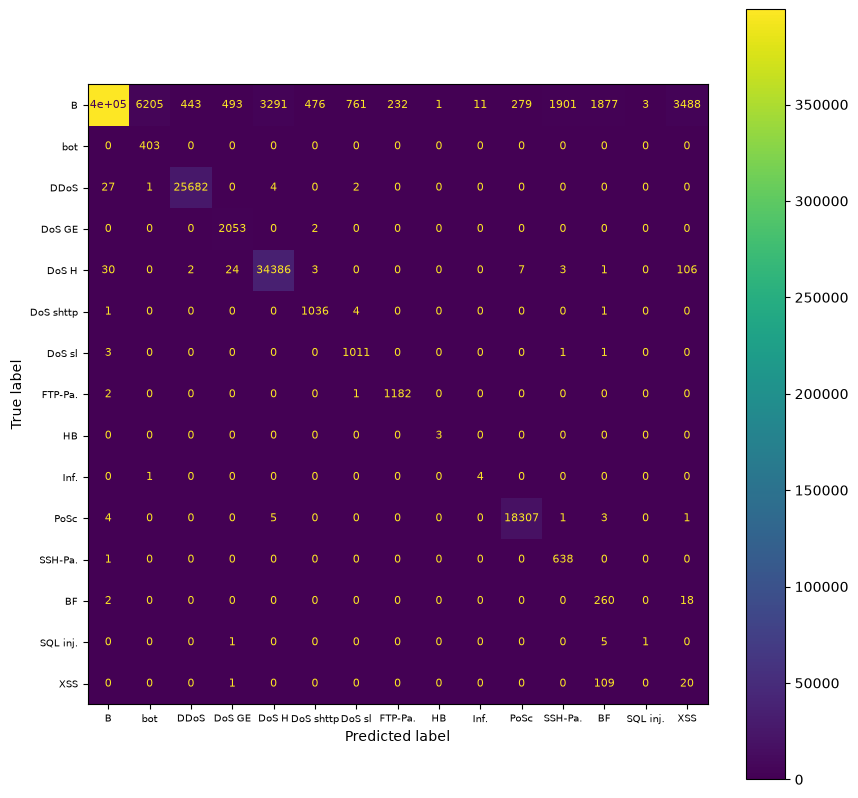

FPR: 0.046469147122451614
alert precision: 0.8112834709560403
macro attack recall: 0.8573104927734609
weighted attack recall: 0.995571903847055


In [52]:
T_cc = int(np.percentile(vals, 50))
cc_strategy = {c: T_cc for c, n in counts.items() if n > T_cc}

cc = ClusterCentroids(sampling_strategy=cc_strategy, 
                      estimator=MiniBatchKMeans(n_init=3, batch_size=4096),
                      random_state=RANDOM_STATE)
X_train_cc, y_train_cc = cc.fit_resample(X_train, y_train)

xgb_cc = XGBClassifier(**hyper_params)
xgb_cc.fit(X_train_cc, y_train_cc, eval_set=eval_set, verbose=0)

preds_cc = xgb_cc.predict(X_test)
evaluate(preds_cc, y_test, le.classes_, "Cluster Centroids (under)")

del cc, xgb_cc, preds_cc

### 3.2 Selection
Selection is split into 2 further groups: Controlled an Cleaning. Controlled involves reducing majority classes down to an arbitrary user-specified amount (we will use third quartile as above), and cleaning involves using an algorithm to remove observations that follow a certain criteria, thus the amount of samples at the end can not be user-specified. 

Cleaning  algorithms are computationally expensive, and for this reason we will combine controlled and cleaning methods into one pipeline. Controlled selection will vastly reduce the load fed into the cleaning section.

--- random -> ENN ---
accuracy: 0.9633
                           precision    recall  f1-score   support

                   BENIGN       1.00      0.96      0.98    418794
                      Bot       0.04      1.00      0.07       403
                     DDoS       0.99      1.00      1.00     25716
            DoS GoldenEye       0.70      1.00      0.82      2055
                 DoS Hulk       0.90      0.99      0.94     34562
         DoS Slowhttptest       0.75      0.99      0.85      1042
            DoS slowloris       0.48      0.99      0.65      1016
              FTP-Patator       0.69      1.00      0.81      1185
               Heartbleed       0.75      1.00      0.86         3
             Infiltration       0.33      0.40      0.36         5
                 PortScan       0.99      0.99      0.99     18321
              SSH-Patator       0.66      0.99      0.79       639
  Web Attack  Brute Force       0.51      0.91      0.66       280
Web Attack  Sql Inject

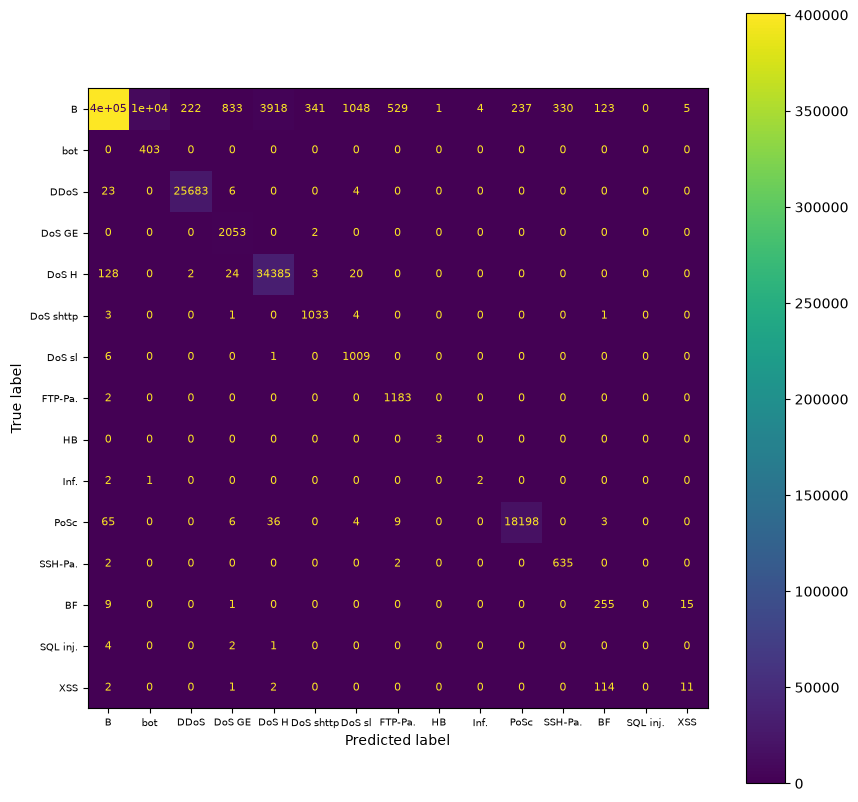

FPR: 0.043009212166363414
alert precision: 0.8227770774750315
macro attack recall: 0.8112688430932619
weighted attack recall: 0.9940138700154632


In [53]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler, EditedNearestNeighbours

T_rus = int(np.percentile(vals, 50))
rus_strategy = {c: T_rus for c, n in counts.items() if n > T_rus}

pipe = Pipeline([
    ('rus', RandomUnderSampler(sampling_strategy=rus_strategy, random_state=RANDOM_STATE)), 
    ('enn', EditedNearestNeighbours(n_jobs=-1)),
    ('clf', XGBClassifier(**hyper_params)),
])
pipe.fit(X_train, y_train, clf__eval_set=eval_set, clf__verbose=0)

preds_sel = pipe.predict(X_test)
evaluate(preds_sel, y_test, le.classes_, "random -> ENN")

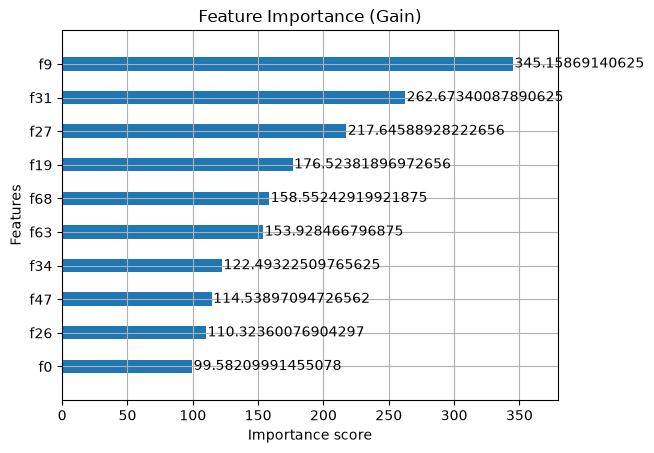

In [54]:
plot_importance(pipe['clf'], importance_type='gain', height=0.4, max_num_features=10)
plt.title('Feature Importance (Gain)')
plt.show()

del pipe, preds_sel, cc_strategy, time_strategy

## 4. Oversampling

We will try two methods of oversampling:
- Naive random,
- SMOTE.

These will both be using methods from the imbalanced learn library. For the sake of fairness, the strategy will be to bring each class to have a frequency equal to the median frequency (of the training set). So, if the median is 5,000, the classes with the least frequent half will be oversampled up to 5,000 entires.

In [55]:
from collections import Counter
counts = Counter(y_train)
T = int(np.median(list(counts.values())))
k = 5
strategy = {c: T for c, n in counts.items() if k < n < T}

### 4.1 Naive Random
The simplest oversampling method would be naive random - sampling with replacement. This would allow rows of minority classes to be duplicated multiple times. While this could potentially help some rare classes (likely would not help classes with ~10 entries), it is functionally the same as changing the weight of the class from (2). 

Despite this, we will still trial the method.

--- Naive oversampling (median) ---
accuracy: 0.9977
                           precision    recall  f1-score   support

                   BENIGN       1.00      1.00      1.00    418794
                      Bot       0.69      0.62      0.66       403
                     DDoS       1.00      1.00      1.00     25716
            DoS GoldenEye       1.00      1.00      1.00      2055
                 DoS Hulk       1.00      0.99      1.00     34562
         DoS Slowhttptest       0.95      0.99      0.97      1042
            DoS slowloris       1.00      0.99      0.99      1016
              FTP-Patator       1.00      0.99      1.00      1185
               Heartbleed       1.00      1.00      1.00         3
             Infiltration       1.00      0.80      0.89         5
                 PortScan       0.99      1.00      0.99     18321
              SSH-Patator       0.97      0.95      0.96       639
  Web Attack  Brute Force       0.74      0.61      0.67       280
Web Atta

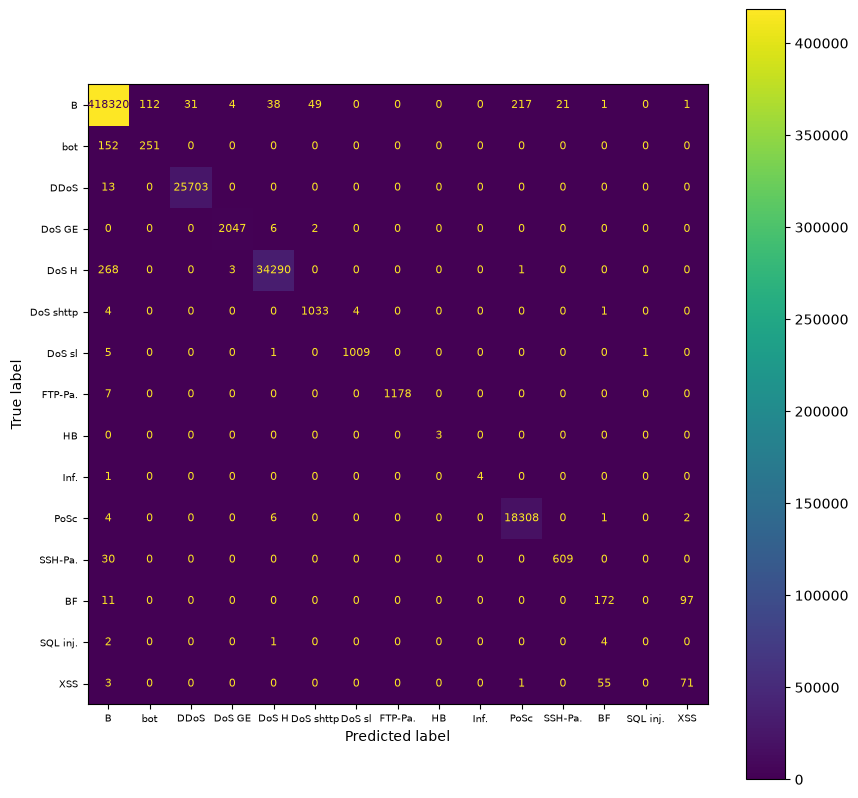

FPR: 0.0011318213727990372
alert precision: 0.9922660479505027
macro attack recall: 0.8215648475577056
weighted attack recall: 0.9919638255002109


In [56]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=RANDOM_STATE, sampling_strategy=strategy)
X_train_r, y_train_r = ros.fit_resample(X_train, y_train)

xgb_ros = XGBClassifier(**hyper_params)
xgb_ros.fit(X_train_r, y_train_r, eval_set = eval_set, verbose=0)

preds_ros = xgb_ros.predict(X_test)
evaluate(preds_ros, y_test, le.classes_, "Naive oversampling (median)")

del ros, xgb_ros, preds_ros

### 4.2 SMOTE - synthetic minority oversampling technique

Creates entries in rare classes by interpolating between 2 actually existing entries. For the sake of the test, I will allow very small classes to also be SMOTE'd. Even classes which have <10 entries. It will be interesting to see how the model changes when it recieves thousands of synthetic data points.

--- SMOTE (median) ---
accuracy: 0.9977
                           precision    recall  f1-score   support

                   BENIGN       1.00      1.00      1.00    418794
                      Bot       0.71      0.62      0.66       403
                     DDoS       1.00      1.00      1.00     25716
            DoS GoldenEye       1.00      0.99      0.99      2055
                 DoS Hulk       1.00      0.99      1.00     34562
         DoS Slowhttptest       0.95      0.99      0.97      1042
            DoS slowloris       1.00      0.99      0.99      1016
              FTP-Patator       1.00      0.99      1.00      1185
               Heartbleed       1.00      1.00      1.00         3
             Infiltration       1.00      0.80      0.89         5
                 PortScan       0.99      1.00      0.99     18321
              SSH-Patator       0.97      0.96      0.96       639
  Web Attack  Brute Force       0.76      0.55      0.64       280
Web Attack  Sql Injec

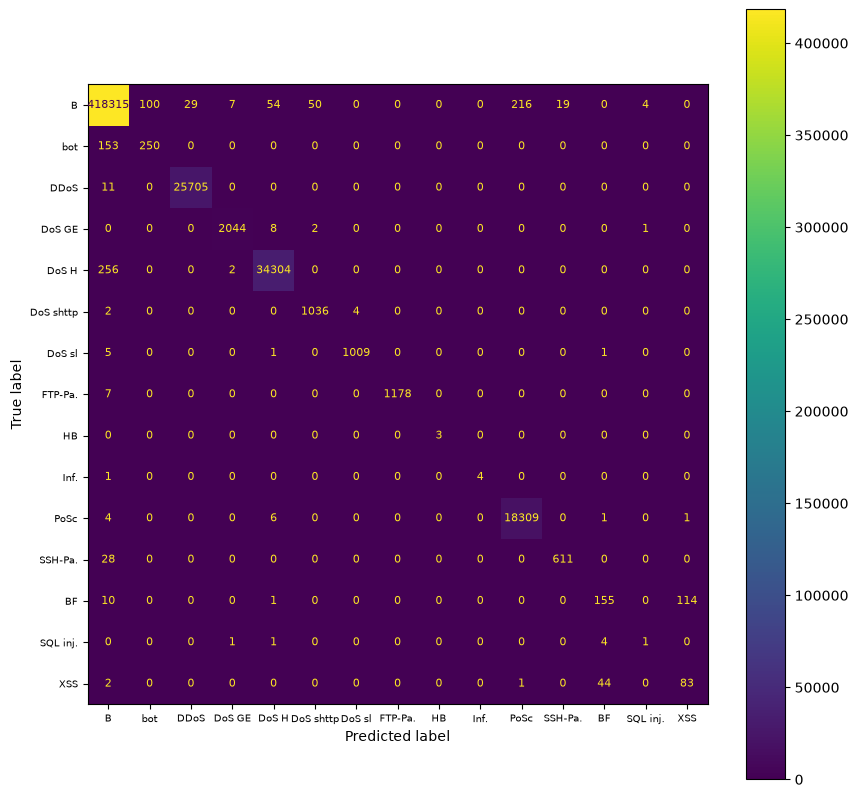

FPR: 0.0011437604168159047
alert precision: 0.992127829061431
macro attack recall: 0.8342116831951293
weighted attack recall: 0.992127829061431


In [57]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(sampling_strategy=strategy, k_neighbors=k)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

xgb_sm = XGBClassifier(**hyper_params)
xgb_sm.fit(X_train_sm, y_train_sm, eval_set = eval_set, verbose=0)

preds_sm = xgb_sm.predict(X_test)
evaluate(preds_sm, y_test, le.classes_, "SMOTE (median)")

del xgb_sm, preds_sm

## 5. synthesis
random undersampling -> SMOTE -> ENN
random understampling and SMOTE will work on mutually exclusive classes - the sets left and right of the median. 

In [58]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, EditedNearestNeighbours
from imblearn.pipeline import Pipeline

T = int(np.percentile(vals, 50))
rus_strategy = {c: T for c, n in counts.items() if n > T}
smt_strategy = {c: T for c, n in counts.items() if n < T}

pipe = Pipeline([
    ('rus', RandomUnderSampler(sampling_strategy=rus_strategy, random_state=RANDOM_STATE)), 
    ('smt', SMOTE(sampling_strategy=strategy, k_neighbors=k)),
    ('enn', EditedNearestNeighbours(n_jobs=-1)),
    ('clf', XGBClassifier(**hyper_params)),
])
pipe.fit(X_train, y_train, clf__eval_set=eval_set)


[0]	validation_0-mlogloss:2.18622
[1]	validation_0-mlogloss:1.92059
[2]	validation_0-mlogloss:1.72270
[3]	validation_0-mlogloss:1.52500
[4]	validation_0-mlogloss:1.36263
[5]	validation_0-mlogloss:1.23145
[6]	validation_0-mlogloss:1.12093
[7]	validation_0-mlogloss:1.02564
[8]	validation_0-mlogloss:0.94453
[9]	validation_0-mlogloss:0.87130
[10]	validation_0-mlogloss:0.80453
[11]	validation_0-mlogloss:0.74908
[12]	validation_0-mlogloss:0.69909
[13]	validation_0-mlogloss:0.65311
[14]	validation_0-mlogloss:0.61140
[15]	validation_0-mlogloss:0.57284
[16]	validation_0-mlogloss:0.53409
[17]	validation_0-mlogloss:0.49957
[18]	validation_0-mlogloss:0.46480
[19]	validation_0-mlogloss:0.43376
[20]	validation_0-mlogloss:0.40880
[21]	validation_0-mlogloss:0.38587
[22]	validation_0-mlogloss:0.36486
[23]	validation_0-mlogloss:0.34537
[24]	validation_0-mlogloss:0.32850
[25]	validation_0-mlogloss:0.31202
[26]	validation_0-mlogloss:0.29694
[27]	validation_0-mlogloss:0.28289
[28]	validation_0-mlogloss:0.2

,steps,"[('rus', ...), ('smt', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](15,)","[ 0, 1, 2,...,12,13,14]"
n_features_in_,int,71
,sampling_strategy,"{np.int64(0): 3162, np.int64(2): 3162, np.int64(3): 3162, np.int64(4): 3162, ...}"
,random_state,5
,replacement,False
Name,Type,Value


--- random -> SMOTE -> ENN ---
accuracy: 0.9825
                           precision    recall  f1-score   support

                   BENIGN       1.00      0.98      0.99    418794
                      Bot       0.08      0.99      0.15       403
                     DDoS       0.99      1.00      1.00     25716
            DoS GoldenEye       0.80      1.00      0.89      2055
                 DoS Hulk       0.99      0.99      0.99     34562
         DoS Slowhttptest       0.81      0.99      0.89      1042
            DoS slowloris       0.75      0.99      0.85      1016
              FTP-Patator       0.83      1.00      0.90      1185
               Heartbleed       0.75      1.00      0.86         3
             Infiltration       0.02      0.80      0.05         5
                 PortScan       0.99      0.99      0.99     18321
              SSH-Patator       0.71      0.97      0.82       639
  Web Attack  Brute Force       0.33      0.59      0.42       280
Web Attack  S

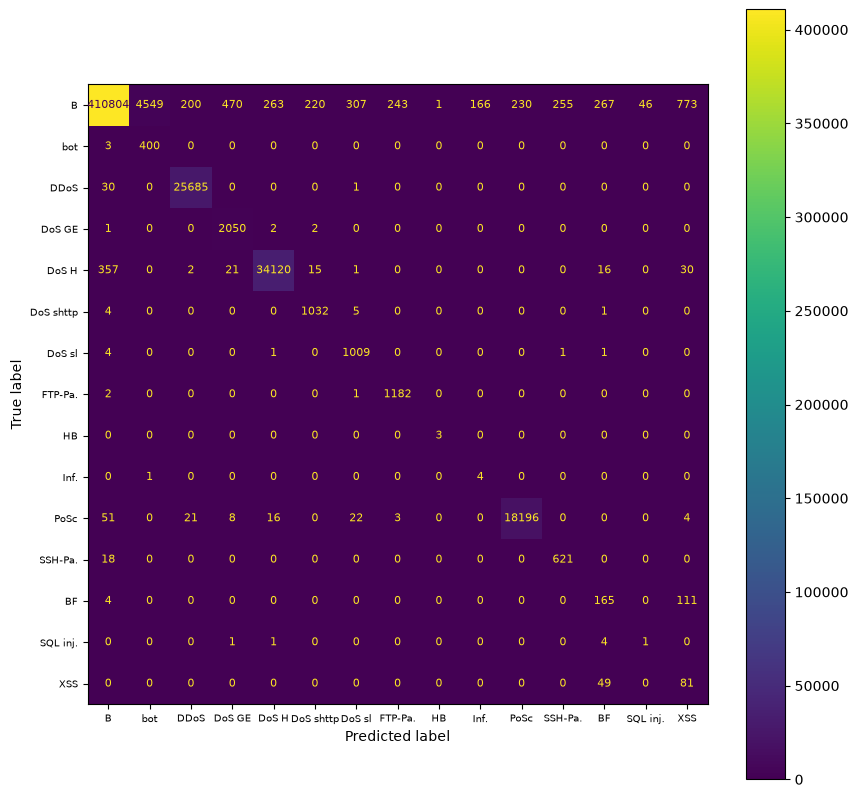

FPR: 0.019078592338954235
alert precision: 0.9103036175710595
macro attack recall: 0.862667022171508
weighted attack recall: 0.9904526498289677


In [59]:
preds_syn = pipe.predict(X_test)
evaluate(preds_syn, y_test, le.classes_, "random -> SMOTE -> ENN")